In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection


font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font)
# -----------------------------------------


In [ ]:
def plot_2d_orthogonal_view():
    """
    Loads and plots the fidelity-vs-delta data in a 2D figure with a
    color gradient.
    """
    # --- 1. File Patterns and Loading ---
    file_lr_vs_delta = "fidel_vs_delta_data/fidelLR_vs_delta_tau_60.csv"
    file_ma_vs_delta = "fidel_vs_delta_data/fidelMA_vs_delta_tau_60.csv"

    # Define the delta axis that corresponds to the data points in the files
    deltas_axis = np.linspace(0.1, 1.0, 200)
    data_lr, data_ma = None, None
    
    # Load LR data if it exists
    if os.path.exists(file_lr_vs_delta):
        fidelities = np.loadtxt(file_lr_vs_delta)
        if fidelities.shape == (200,):
            data_lr = np.c_[deltas_axis, fidelities]
            print(f"Loaded '{file_lr_vs_delta}'")
            
    # Load MA data if it exists
    if os.path.exists(file_ma_vs_delta):
        fidelities = np.loadtxt(file_ma_vs_delta)
        if fidelities.shape == (200,):
            data_ma = np.c_[deltas_axis, fidelities]
            print(f"Loaded '{file_ma_vs_delta}'")

    if data_lr is None and data_ma is None:
        print("\n❌ No data files found.")
        # Tip: Uncomment the line below to generate dummy files for testing.
        # create_dummy_2d_files()
        return

    # --- 2. Setup Custom Diverging Colormap ---
    all_deltas_lr = data_lr[:, 0] if data_lr is not None else []
    all_deltas_ma = data_ma[:, 0] if data_ma is not None else []
    all_deltas = np.concatenate([all_deltas_lr, all_deltas_ma])
    
    if len(all_deltas) == 0:
        print("❌ No data to plot. Exiting.")
        return
        
    d_min, d_max = min(all_deltas), max(all_deltas)
    colors = ["blue", "black", "red"]
    custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_bkr", colors)
    diverging_norm = mcolors.TwoSlopeNorm(vmin=d_min, vcenter=0.5, vmax=d_max)

    # --- 3. Create the 2D Plot ---
    print("🚀 Generating 2D plot...")
    # UPDATED: Removed figsize to use default size
    fig, ax = plt.subplots(dpi = 600)

    # --- 4. Plot the data using LineCollection for gradient coloring ---
    # Plot LR data (dashed)
    # --- BLOCK REPLACED ---
    # Plot LR data using the "plot 2, skip 4" manual loop
    if data_lr is not None:
        x, y = data_lr[:, 0], data_lr[:, 1]
        # Loop with a step of 6 to plot 2 segments and skip 4
        for i in range(0, len(x) - 2, 6):
            # Get the color for the start of the 2-segment chunk
            segment_color = custom_cmap(diverging_norm(x[i]))
            # Plot the 2-segment chunk (3 points)
            ax.plot(
                x[i:i+3],
                y[i:i+3],
                color=segment_color,
                linewidth=2,
                linestyle='-' # The chunk itself is solid
            )
    # --- END REPLACEMENT ---

    # Plot MA data (solid)
    if data_ma is not None:
        x, y = data_ma[:, 0], data_ma[:, 1]
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc_ma = LineCollection(segments, cmap=custom_cmap, norm=diverging_norm)
        lc_ma.set_array(x)
        lc_ma.set_linewidth(2)
        ax.add_collection(lc_ma)

    # --- 5. Customize Plot ---
    # UPDATED: Removed local font sizes to use global rcParams
    legend_elements = [
        Line2D([0], [0], color='gray', lw=2, linestyle='-', label=r'\textbf{fidelMA (Solid)}'),
        Line2D([0], [0], color='gray', lw=2, linestyle='--', label=r'\textbf{fidelLR (Dashed)}')]
    #ax.legend(handles=legend_elements, loc='upper right')
    
    ax.set_xlabel(r'{$\Delta$}')
    ax.set_ylabel(r'{$\mathcal{F}$}')
    #ax.set_title(r'\textbf{Fidelity vs. Delta at a fixed $\tau=60$}')
    
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)
    ax.grid()
    
    # Use one of the LineCollections for the color bar
    sm = lc_ma if data_ma is not None else lc_lr
    #cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.2)
    #cbar.set_label(r'{$\Delta$}')
    
    #plt.tight_layout()
    plt.show()


Loaded 'fidelLR_vs_delta_tau_60.csv'
Loaded 'fidelMA_vs_delta_tau_60.csv'
🚀 Generating 2D plot...


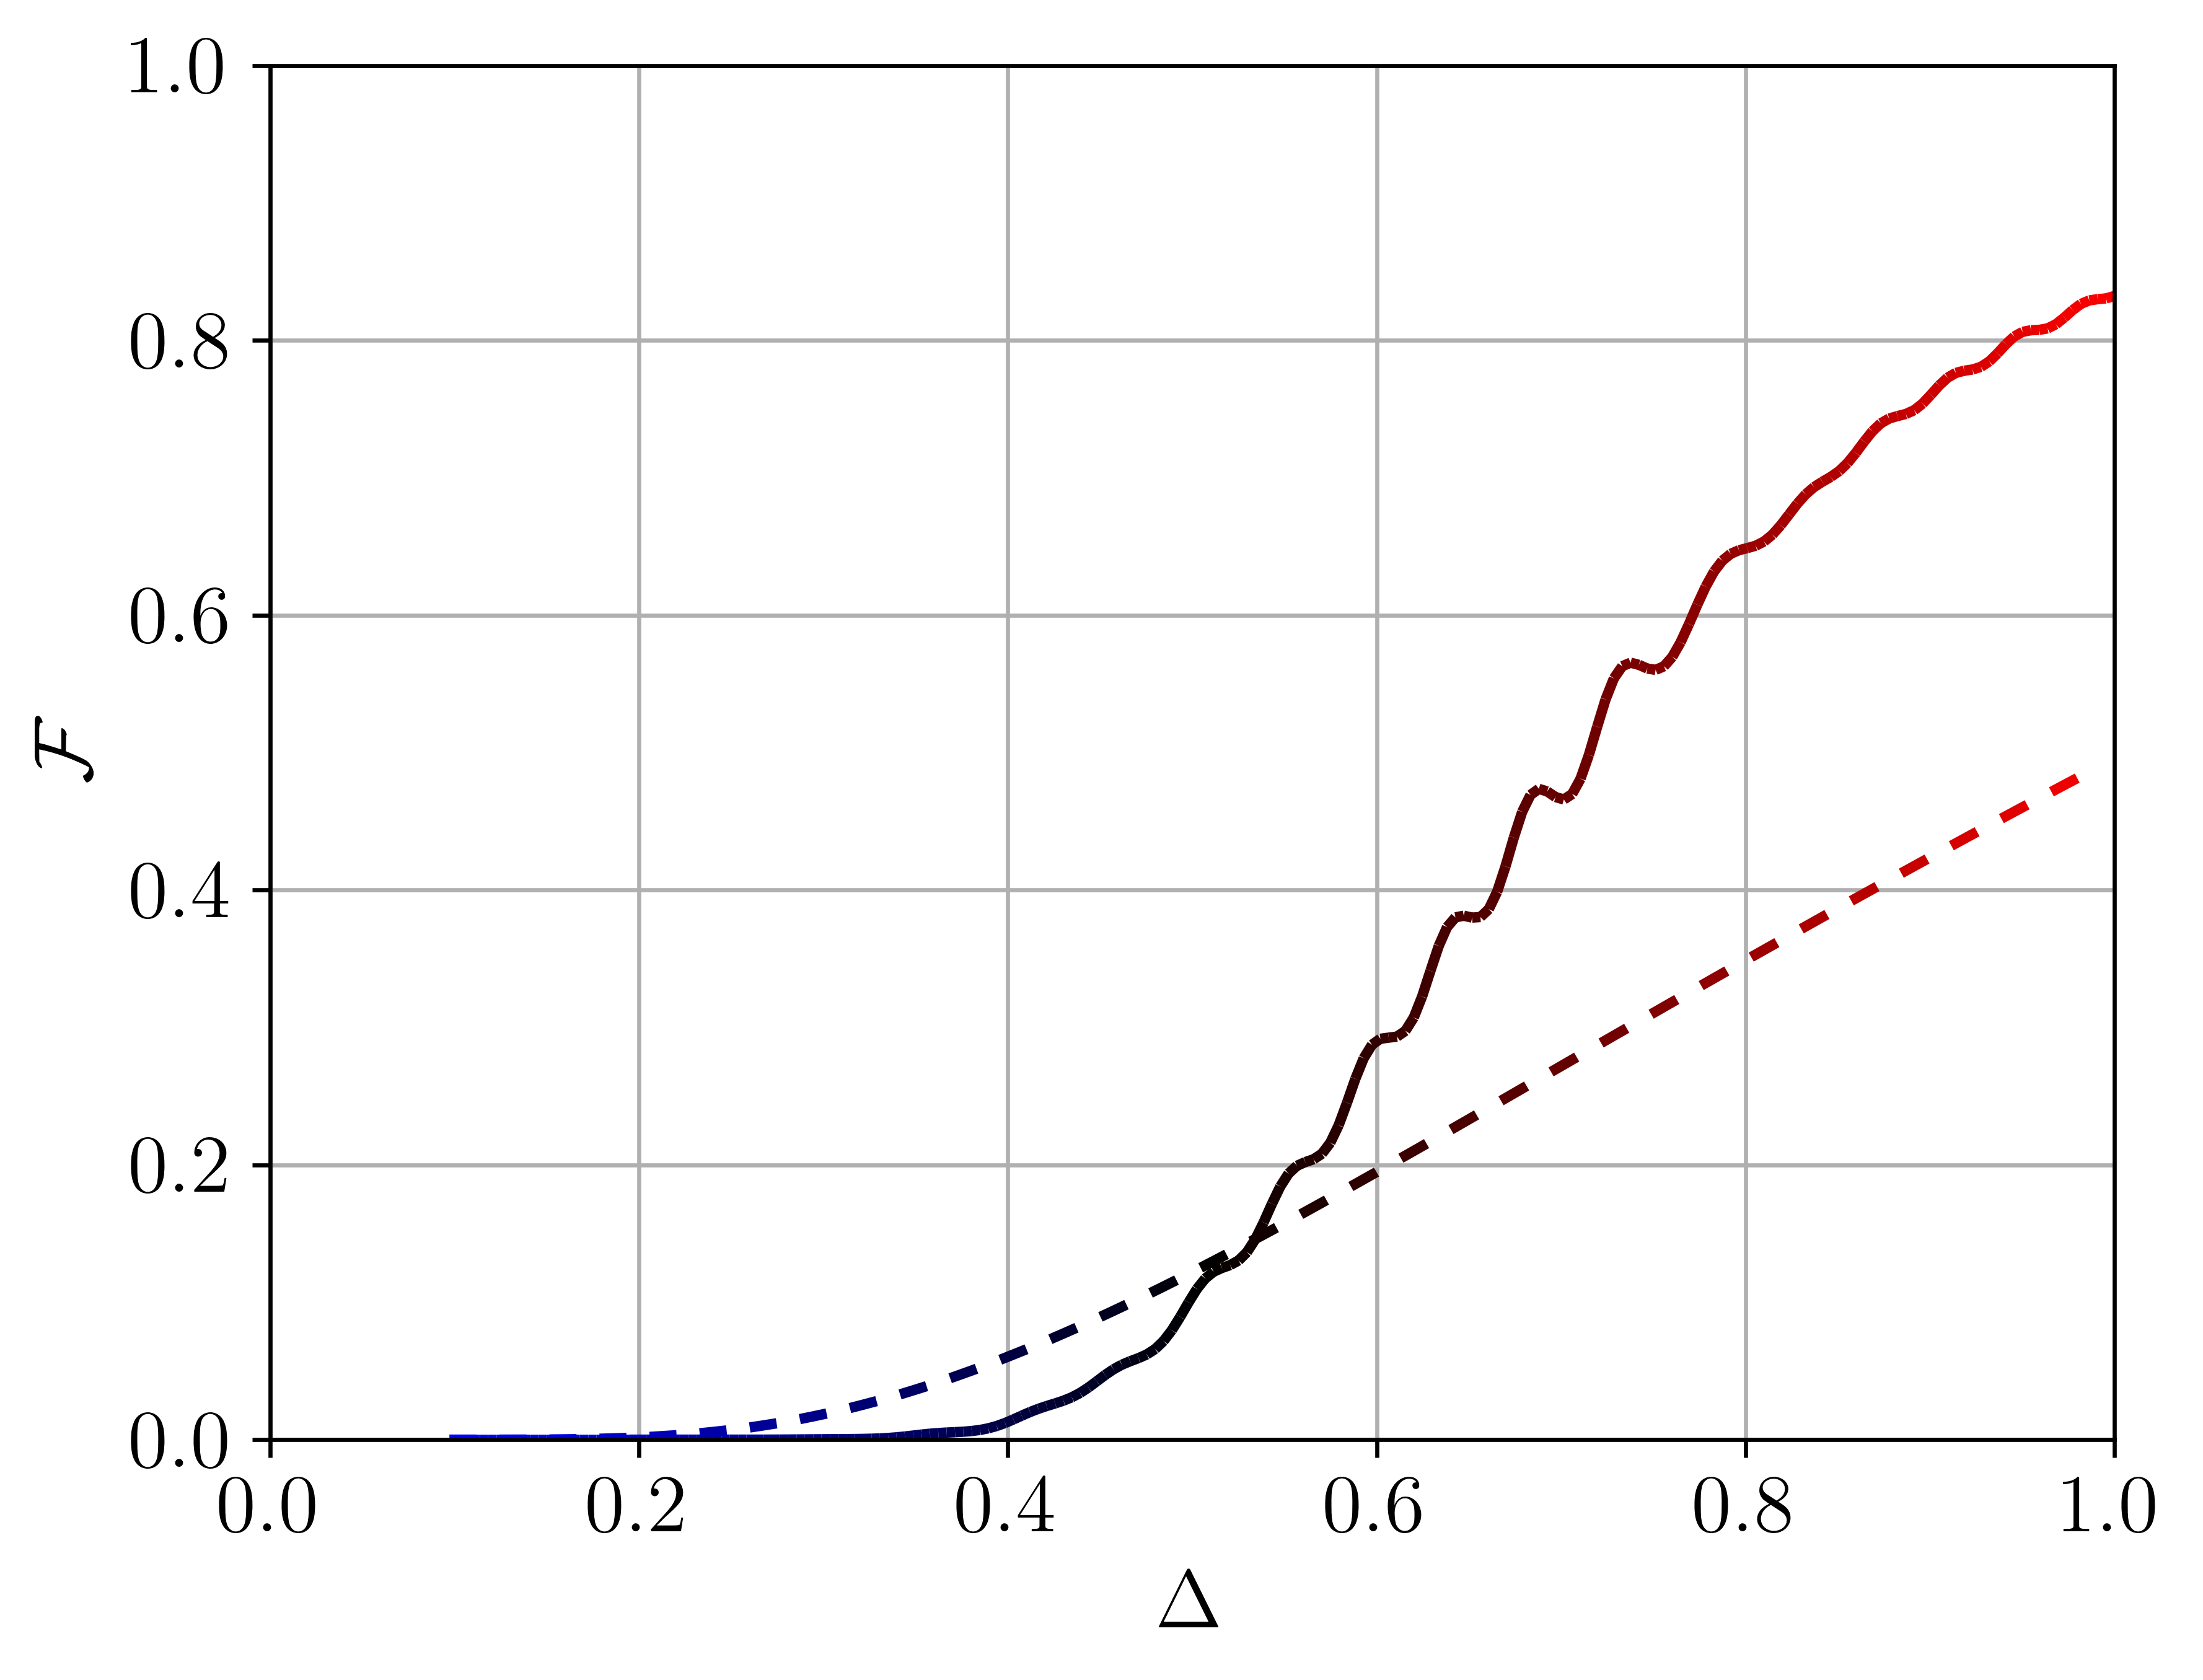

In [3]:
if __name__ == '__main__':
    plot_2d_orthogonal_view()